Wilson-Devinney Style Meshing
============================

**NOTE**: Wilson-Devinney Style meshing requires developer mode in PHOEBE and is meant to be used for testing, not used for science.

Setup
-----------------------------

Let's first make sure we have the latest version of PHOEBE 2.5 installed (uncomment this line if running in an online notebook session such as colab).

In [1]:
#!pip install -I "phoebe>=2.5"

As always, let's do imports and initialize a logger and a new bundle.

In [2]:
import phoebe
from phoebe import u # units
import numpy as np
import matplotlib.pyplot as plt

phoebe.devel_on() # CURRENTLY REQUIRED FOR WD-STYLE MESHING (WHICH IS EXPERIMENTAL)

logger = phoebe.logger()

b = phoebe.default_binary()

Changing Meshing Options
--------------------------------

Next we need to add compute options and change the mesh_style for all stars from 'marching' to 'wd'

In [3]:
b.set_value_all('mesh_method', 'wd')
b.set_value_all('eclipse_method', 'graham')

Adding Datasets
---------------------

Next let's add a mesh dataset so that we can plot our Wilson-Devinney style meshes

In [4]:
b.add_dataset('mesh', compute_times=[0, 0.5], dataset='mesh01', columns=['visibilities'])

<ParameterSet: 85 parameters | contexts: constraint, figure, dataset, compute>

Running Compute
------------------

In [5]:
b.run_compute(irrad_method='none')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.66s/it]


<ParameterSet: 23 parameters | components: secondary, primary>

Plotting
---------------------

Tue, 28 Jul 2026 15:30 matplotlib.axes._base WARNING Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


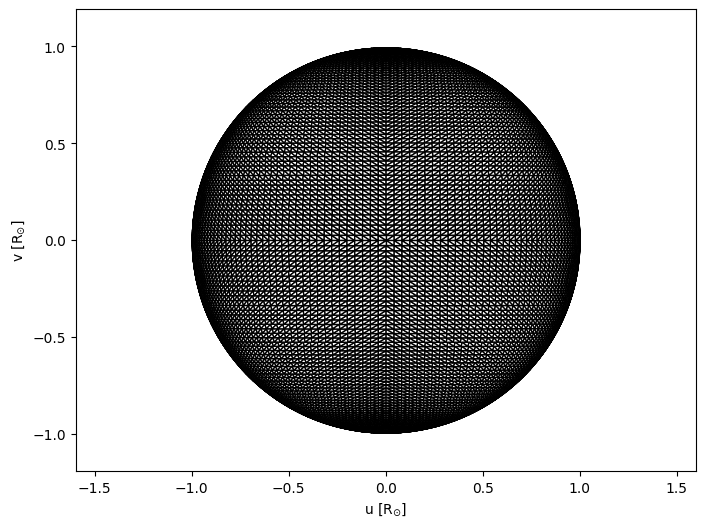

In [6]:
afig, mplfig = b['mesh01@model'].plot(time=0.5, x='us', y='vs',
                                      show=True)

Now let's zoom in so we can see the layout of the triangles.  Note that Wilson-Devinney uses trapezoids, but since PHOEBE uses triangles, we take each of the trapezoids and split it into two triangles.

Tue, 28 Jul 2026 15:30 PARAMETERS   WARNING could not find Parameter match for ec=#2B71B1 at time=00.000000, assuming named color
Tue, 28 Jul 2026 15:30 matplotlib.axes._base WARNING Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


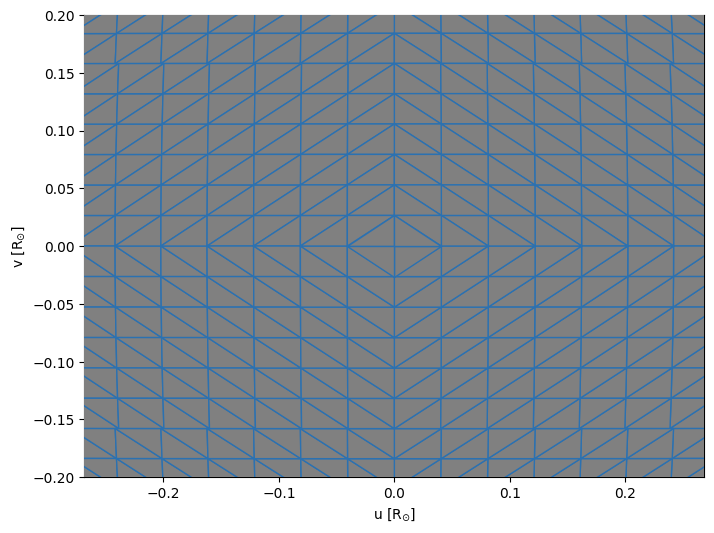

In [7]:
afig, mplfig = b['primary@mesh01@model'].plot(time=0.0,  x='us', y='vs',
                                              ec='blue', fc='gray', 
                                              xlim=(-0.2,0.2), ylim=(-0.2,0.2), 
                                              show=True)

And now looking down from above.  Here you can see the gaps between the surface elements (and you can also see some of the subdivision that's taking place along the limb).

Tue, 28 Jul 2026 15:30 PARAMETERS   WARNING could not find Parameter match for ec=#2B71B1 at time=00.000000, assuming named color
Tue, 28 Jul 2026 15:30 matplotlib.axes._base WARNING Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


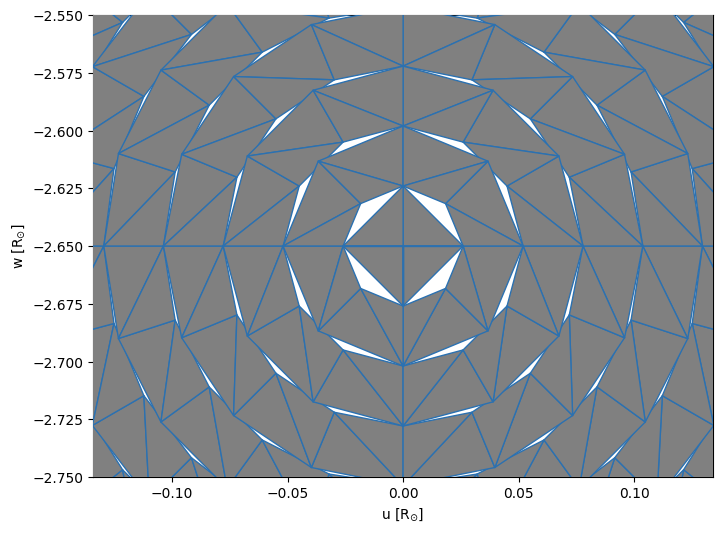

In [8]:
afig, mplfig = b['primary@mesh01@model'].plot(time=0.0, x='us', y='ws', 
                                              ec='blue', fc='gray', 
                                              xlim=(-0.1,0.1), ylim=(-2.75,-2.55), 
                                              show=True)

And see which elements are visible at the current time.  This defaults to use the 'RdYlGn' colormap which will make visible elements green, partially hidden elements yellow, and hidden elements red.  Note that the observer is in the positive w-direction.

Tue, 28 Jul 2026 15:30 PARAMETERS   WARNING could not find Parameter match for ec=face at time=00.000000, assuming named color
Tue, 28 Jul 2026 15:30 matplotlib.axes._base WARNING Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


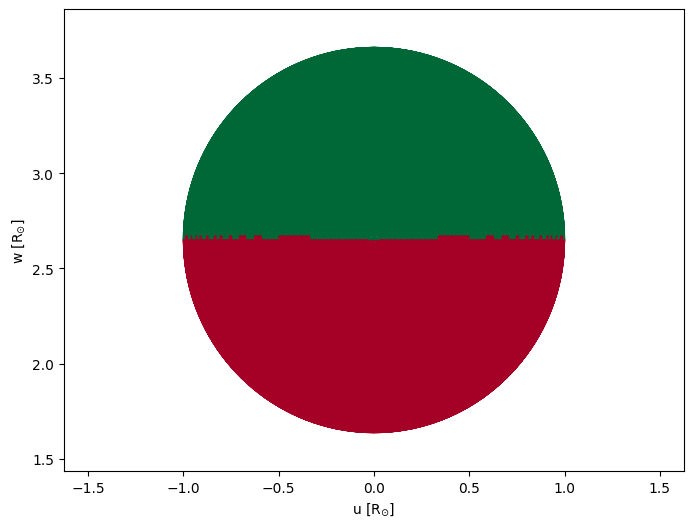

In [9]:
afig, mplfig = b['secondary@mesh01@model'].plot(time=0.0, x='us', y='ws', 
                                                ec='face', fc='visibilities',
                                                show=True)